<a href="https://colab.research.google.com/github/TingyuZhao19/MSSP6070/blob/main/Assignments/ASSIGNMENT_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import pandas as pd

path = Path("/content/drive/MyDrive/MSSP607/Modules/Week08/InternetSales.csv")
df = pd.read_csv(path, encoding='latin-1', low_memory=False)
display(df.head())

,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,...,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1912.1544,1912.1544,3399.99,271.9992,84.9998,NaN,NaN,1/19/2011,1/31/2011,1/26/2011
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1265.6195,1265.6195,2319.99,185.5992,57.9998,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,8.2205,8.2205,21.98,1.7584,0.5495,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
3,3,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1481.9379,1481.9379,2384.07,190.7256,59.6018,NaN,NaN,5/3/2013,5/15/2013,5/10/2013
4,4,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,10.8423,10.8423,28.99,2.3192,0.7248,NaN,NaN,5/3/2013,5/15/2013,5/10/2013


## 1. Internet sales of Adventure Works by year for each Country Region

In [3]:
# Convert the 'OrderDate' column to datetime objects using pd.to_datetime.
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')
display(df.head())

,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,...,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1912.1544,1912.1544,3399.99,271.9992,84.9998,NaN,NaN,2011-01-19,1/31/2011,1/26/2011
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1265.6195,1265.6195,2319.99,185.5992,57.9998,NaN,NaN,2013-01-18,1/30/2013,1/25/2013
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,8.2205,8.2205,21.98,1.7584,0.5495,NaN,NaN,2013-01-18,1/30/2013,1/25/2013
3,3,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1481.9379,1481.9379,2384.07,190.7256,59.6018,NaN,NaN,2013-05-03,5/15/2013,5/10/2013
4,4,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,10.8423,10.8423,28.99,2.3192,0.7248,NaN,NaN,2013-05-03,5/15/2013,5/10/2013


## Extract year


In [4]:
# Extract the year from the `OrderDate` column and create a new column called `OrderYear`.
df['OrderYear'] = df['OrderDate'].dt.year
display(df.head())

,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,...,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate,OrderYear
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1912.1544,3399.99,271.9992,84.9998,NaN,NaN,2011-01-19,1/31/2011,1/26/2011,2011
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1265.6195,2319.99,185.5992,57.9998,NaN,NaN,2013-01-18,1/30/2013,1/25/2013,2013
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,8.2205,21.98,1.7584,0.5495,NaN,NaN,2013-01-18,1/30/2013,1/25/2013,2013
3,3,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1481.9379,2384.07,190.7256,59.6018,NaN,NaN,2013-05-03,5/15/2013,5/10/2013,2013
4,4,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,10.8423,28.99,2.3192,0.7248,NaN,NaN,2013-05-03,5/15/2013,5/10/2013,2013


## Group and aggregate

In [5]:
# Group the DataFrame by `OrderYear` and `EnglishCountryRegionName` and calculate the sum of `SalesAmount`.
sales_by_year_country = df.groupby(['OrderYear', 'EnglishCountryRegionName'])['SalesAmount'].sum().reset_index()
display(sales_by_year_country.head())

,OrderYear,EnglishCountryRegionName,SalesAmount
0,2010,Australia,20909.7800
1,2010,Canada,3578.2700
2,2010,France,3399.9900
3,2010,United Kingdom,699.0982
4,2010,United States,14833.8982


## Display results


In [6]:
display(sales_by_year_country)

,OrderYear,EnglishCountryRegionName,SalesAmount
0,2010,Australia,2.090978e+04
1,2010,Canada,3.578270e+03
2,2010,France,3.399990e+03
3,2010,United Kingdom,6.990982e+02
4,2010,United States,1.483390e+04
5,2011,Australia,2.563732e+06
6,2011,Canada,5.715718e+05
7,2011,France,4.108453e+05
8,2011,Germany,5.205002e+05
9,2011,United Kingdom,5.505912e+05


## Visualize sales data


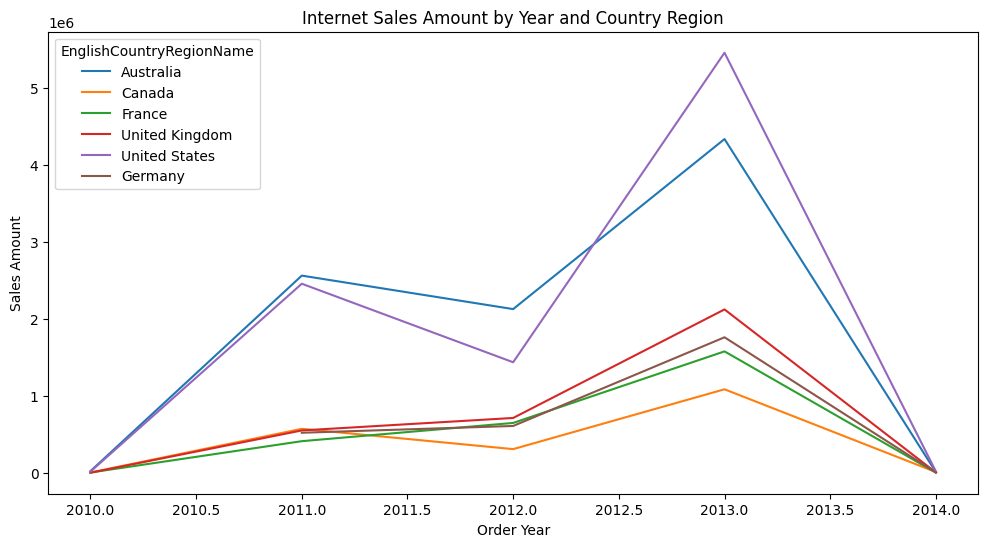

In [7]:
# Create a plot to visualize the `sales_by_year_country` DataFrame, showing sales amount by year and country.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_by_year_country, x='OrderYear', y='SalesAmount', hue='EnglishCountryRegionName')
plt.title('Internet Sales Amount by Year and Country Region')
plt.xlabel('Order Year')
plt.ylabel('Sales Amount')
plt.show()

## 2. Summary statistics including min, max, and standard deviation for Yearly Income, Gender by Country Regions



In [8]:
# Group the DataFrame by `EnglishCountryRegionName` and `Gender`, and calculate the minimum, maximum, and standard deviation of `YearlyIncome`.
income_summary = df.groupby(['EnglishCountryRegionName', 'Gender'])['YearlyIncome'].agg(count='count', mean='mean', min='min', max='max', std='std')

## Display results


In [9]:
# Display the `income_summary` DataFrame with the summary statistics.
display(income_summary)

count          mean    min     max  \
EnglishCountryRegionName Gender                                       
Australia                F        6685  67060.583396  10000  160000   
                         M        6660  65412.912913  10000  170000   
Canada                   F        3648  58651.315789  10000  170000   
                         M        3972  61460.221551  10000  170000   
France                   F        2781  39367.134124  10000  110000   
                         M        2777  39805.545553  10000  110000   
Germany                  F        2820  48287.234043  10000  130000   
                         M        2805  46730.837790  10000  130000   
United Kingdom           F        3401  56518.670979  10000  170000   
                         M        3505  55771.754636  10000  170000   
United States            F       10682  64766.897585  10000  170000   
                         M       10662  65450.196961  10000  170000   

                                          std  
EnglishCountryRegionName Gender                
Australia                F       30613.956169  
                         M       32550.778171  
Canada                   F       19435.158438  
                         M       22702.851581  
France                   F       28421.836245  
                         M       28665.660622  
Germany                  F       37622.814569  
                         M       37487.619366  
United Kingdom           F       51130.689140  
                         M       50963.707551  
United States            F       25498.805483  
                         M       26520.348175

## Visualization

In [10]:
# Reset the index of `income_summary` to make 'EnglishCountryRegionName' and 'Gender' regular columns.
income_summary = income_summary.reset_index()
display(income_summary.head())

,EnglishCountryRegionName,Gender,count,mean,min,max,std
0,Australia,F,6685,67060.583396,10000,160000,30613.956169
1,Australia,M,6660,65412.912913,10000,170000,32550.778171
2,Canada,F,3648,58651.315789,10000,170000,19435.158438
3,Canada,M,3972,61460.221551,10000,170000,22702.851581
4,France,F,2781,39367.134124,10000,110000,28421.836245


In [11]:
# Transform the income_summary DataFrame into a long format suitable for plotting the min, max, and std deviations using pd.melt.
income_melted = pd.melt(income_summary, id_vars=['EnglishCountryRegionName', 'Gender'], var_name='Statistic', value_name='YearlyIncome')
display(income_melted.head())

,EnglishCountryRegionName,Gender,Statistic,YearlyIncome
0,Australia,F,count,6685.0
1,Australia,M,count,6660.0
2,Canada,F,count,3648.0
3,Canada,M,count,3972.0
4,France,F,count,2781.0


## Visualize income summary



<Figure size 1400x800 with 0 Axes>

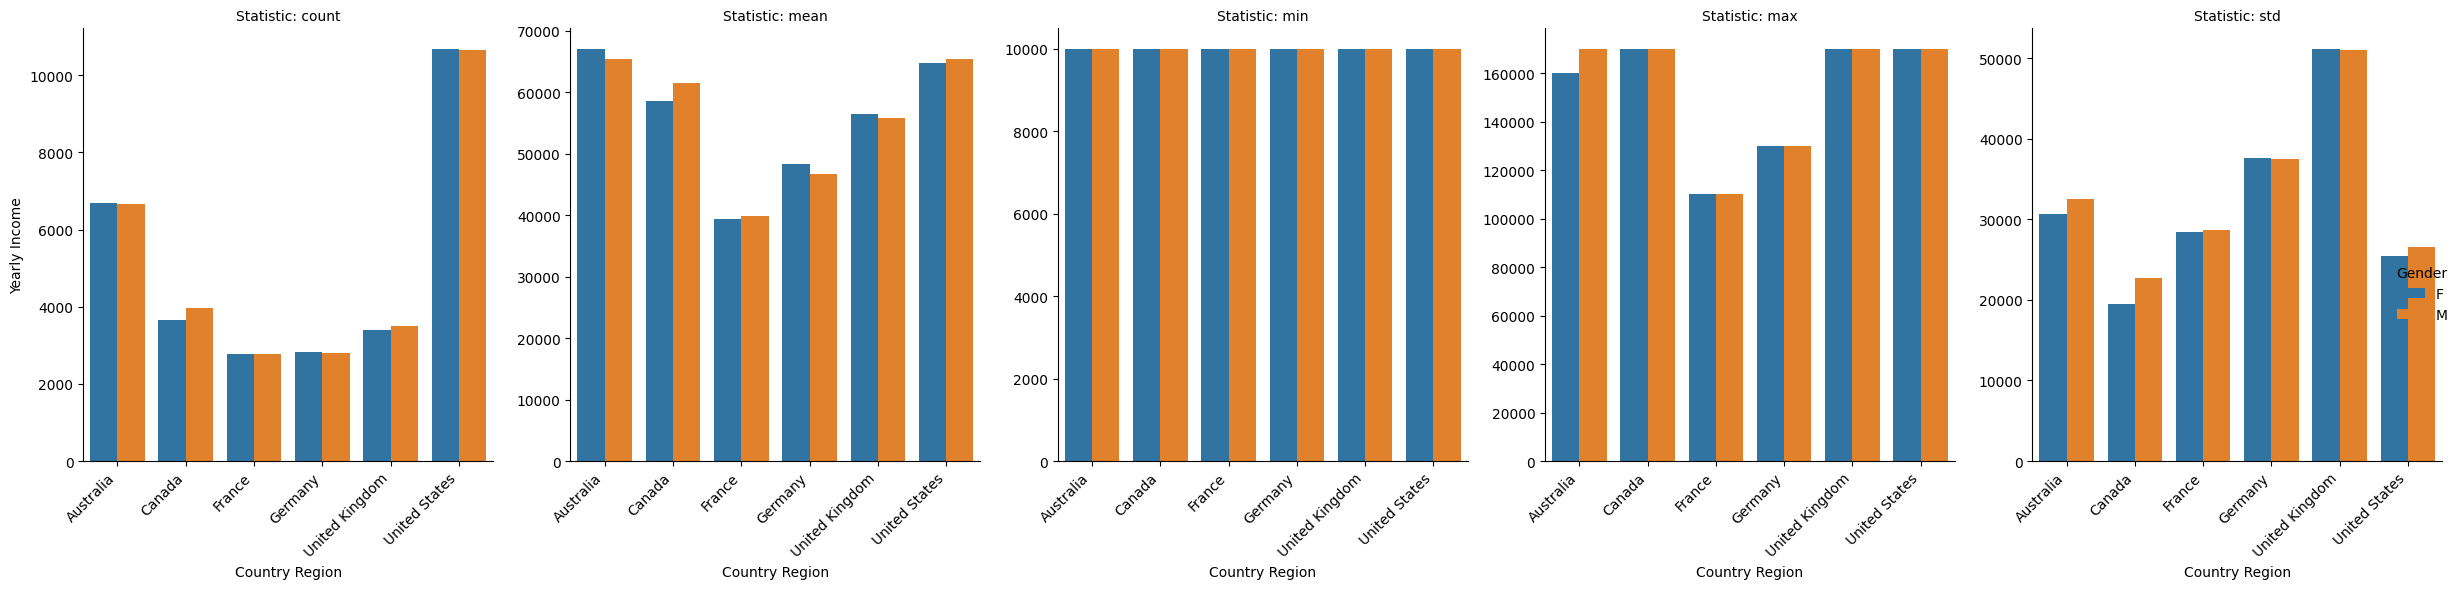

In [12]:
# Create a plot to visualize the income summary data.
plt.figure(figsize=(14, 8))
g = sns.catplot(data=income_melted, x='EnglishCountryRegionName', y='YearlyIncome', hue='Gender', col='Statistic', kind='bar', sharey=False, height=6, aspect=0.8)
g.set_axis_labels("Country Region", "Yearly Income")
g.set_titles("Statistic: {col_name}")
g.set_xticklabels(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Average price of the product category that generates the most sales


In [13]:
#Group the DataFrame by product category and calculate the sum of sales for each category.
display(df.columns)

Index(['ID', 'CustomerKey', 'GeographyKey', 'City', 'CountryRegionCode',
       'EnglishCountryRegionName', 'CustomerAlternateKey', 'Title',
       'FirstName', 'MiddleName', 'LastName', 'NameStyle', 'BirthDate',
       'MaritalStatus', 'Suffix', 'Gender', 'EmailAddress', 'YearlyIncome',
       'TotalChildren', 'NumberChildrenAtHome', 'EnglishEducation',
       'SpanishEducation', 'FrenchEducation', 'EnglishOccupation',
       'SpanishOccupation', 'FrenchOccupation', 'HouseOwnerFlag',
       'NumberCarsOwned', 'AddressLine1', 'AddressLine2', 'Phone',
       'DateFirstPurchase', 'CommuteDistance', 'ProductKey',
       'EnglishProductName', 'OrderDateKey', 'DueDateKey', 'ShipDateKey',
       'CustomerKey.1', 'PromotionKey', 'CurrencyKey', 'SalesTerritoryKey',
       'SalesOrderNumber', 'SalesOrderLineNumber', 'RevisionNumber',
       'OrderQuantity', 'UnitPrice', 'ExtendedAmount', 'UnitPriceDiscountPct',
       'DiscountAmount', 'ProductStandardCost', 'TotalProductCost',
       'SalesAmo

In [14]:
category_sales = df.groupby('EnglishProductName')['SalesAmount'].sum().reset_index()
display(category_sales.head())
top_category_row = category_sales.loc[category_sales['SalesAmount'].idxmax()]
top_category = top_category_row['EnglishProductName']
print(f"The top selling product category is: {top_category}")

,EnglishProductName,SalesAmount
0,AWC Logo Cap,19688.1
1,All-Purpose Bike Stand,39591.0
2,Bike Wash - Dissolver,7218.6
3,"Classic Vest, L",12382.5
4,"Classic Vest, M",12636.5


The top selling product category is: Mountain-200 Black, 46


### Filter data for the top category

In [15]:
# Create a new DataFrame containing only the data for the top-selling product category.
top_category_df = df[df['EnglishProductName'] == top_category]
display(top_category_df.head())

,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,...,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate,OrderYear
96,96,11016,329,Imperial Beach,US,United States,AW00011016,NaN,Wyatt,L,...,1251.9813,2294.99,183.5992,57.3748,NaN,NaN,2013-02-09,2/21/2013,2/16/2013,2013
99,99,11017,39,Sunbury,AU,Australia,AW00011017,NaN,Shannon,NaN,...,1251.9813,2294.99,183.5992,57.3748,NaN,NaN,2013-01-01,1/13/2013,1/8/2013,2013
143,143,11020,53,Metchosin,CA,Canada,AW00011020,NaN,Jordan,C,...,1251.9813,2294.99,183.5992,57.3748,NaN,NaN,2012-12-29,1/10/2013,1/5/2013,2012
145,145,11021,536,Beaverton,US,United States,AW00011021,NaN,Destiny,NaN,...,1251.9813,2294.99,183.5992,57.3748,NaN,NaN,2013-01-23,2/4/2013,1/30/2013,2013
176,176,11027,40,Warrnambool,AU,Australia,AW00011027,NaN,Jessie,R,...,1251.9813,2294.99,183.5992,57.3748,NaN,NaN,2013-05-23,6/4/2013,5/30/2013,2013


### Calculate the average price for the top category


In [16]:
average_price_top_category = top_category_df['SalesAmount'].mean()
print(f"The average price for the top selling product category ({top_category}) is: {average_price_top_category:.2f}")

The average price for the top selling product category (Mountain-200 Black, 46) is: 2215.27


### The top 10

In [17]:
top10_products = category_sales.sort_values(by='SalesAmount', ascending=False).head(10)['EnglishProductName'].tolist()
work = df[df['EnglishProductName'].isin(top10_products)].copy()

In [18]:
simple_avg = (work.groupby('EnglishProductName')['UnitPrice']
                 .mean().rename('AvgPrice_Simple'))

# Weighted average price per product
if 'OrderQuantity' in work.columns:
    work['OrderQuantity'] = pd.to_numeric(work['OrderQuantity'], errors='coerce')
    wcol = 'OrderQuantity'
else:
    wcol = 'SalesAmount'

weighted = (work.assign(wx = work['UnitPrice'] * work[wcol])
                 .groupby('EnglishProductName')
                 .agg(AvgPrice_Weighted=('wx', 'sum'),
                      Weight_Sum=(wcol, 'sum')))
weighted['AvgPrice_Weighted'] = weighted['AvgPrice_Weighted'] / weighted['Weight_Sum']
weighted = weighted[['AvgPrice_Weighted']]

# Context and final table ordered by total sales
ctx = work.groupby('EnglishProductName')['SalesAmount'].sum().rename('TotalSales')
q3_top10_products = (ctx.to_frame().join(simple_avg).join(weighted)
                        .reset_index()
                        .sort_values('TotalSales', ascending=False))
display(q3_top10_products)

,EnglishProductName,TotalSales,AvgPrice_Simple,AvgPrice_Weighted
2,"Mountain-200 Black, 46",1.373470e+06,2215.273465,2215.273465
1,"Mountain-200 Black, 42",1.363142e+06,2220.101129,2220.101129
3,"Mountain-200 Silver, 38",1.339463e+06,2247.420789,2247.420789
5,"Mountain-200 Silver, 46",1.301100e+06,2243.276032,2243.276032
0,"Mountain-200 Black, 38",1.294866e+06,2224.855913,2224.855913
4,"Mountain-200 Silver, 42",1.257435e+06,2245.418880,2245.418880
6,"Road-150 Red, 48",1.205877e+06,3578.270000,3578.270000
9,"Road-150 Red, 62",1.202299e+06,3578.270000,3578.270000
7,"Road-150 Red, 52",1.080638e+06,3578.270000,3578.270000
8,"Road-150 Red, 56",1.055590e+06,3578.270000,3578.270000


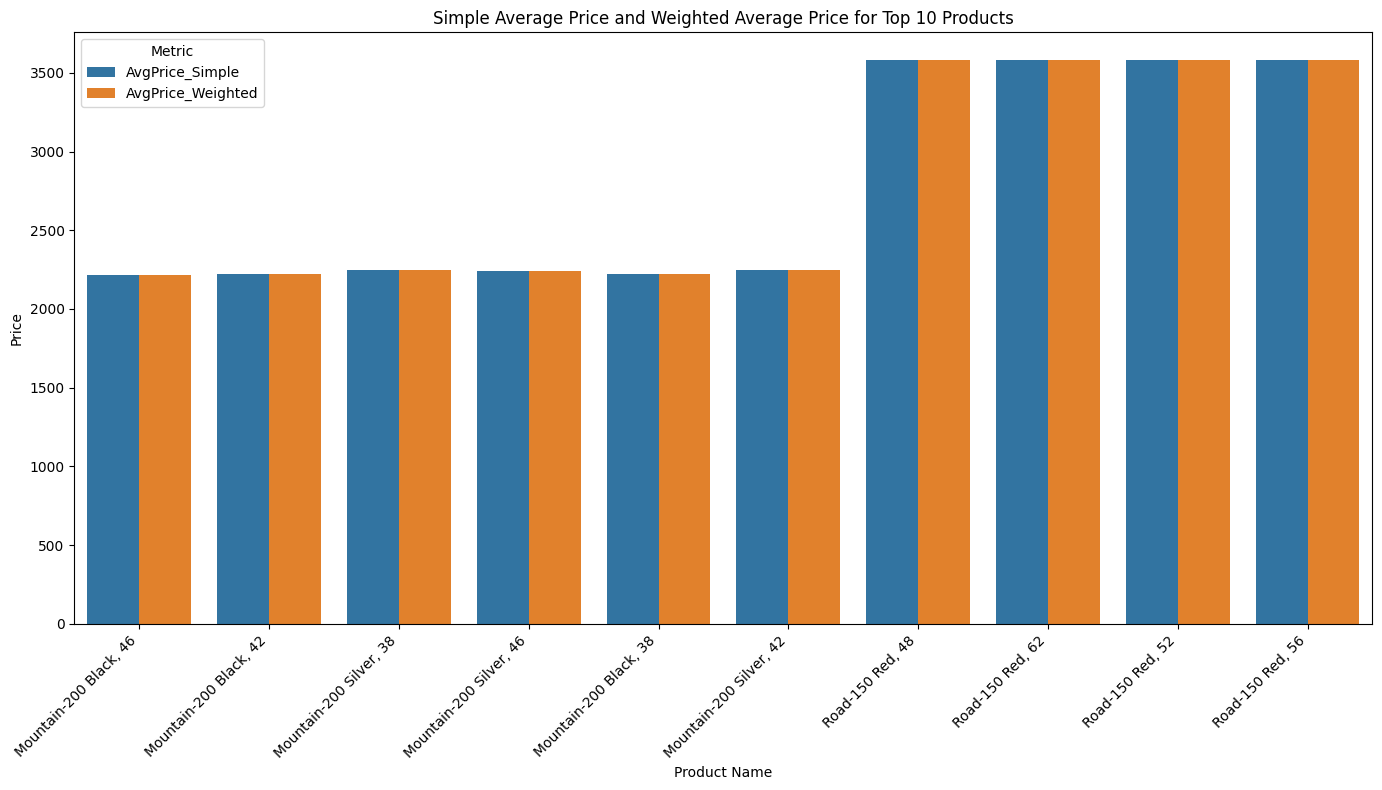

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the DataFrame to long format for easier plotting, excluding 'TotalSales'
q3_melted = q3_top10_products.melt(id_vars='EnglishProductName',
                                   value_vars=['AvgPrice_Simple', 'AvgPrice_Weighted'],
                                   var_name='Metric', value_name='Value')

plt.figure(figsize=(14, 8))
sns.barplot(data=q3_melted, x='EnglishProductName', y='Value', hue='Metric')
plt.title('Simple Average Price and Weighted Average Price for Top 10 Products')
plt.xlabel('Product Name')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Does owning a home make a difference in sales


In [20]:
grouped_by_ownership = df.groupby('HouseOwnerFlag')

### Calculate average sales

In [21]:
# Calculate the average of the `SalesAmount` for each group.
average_sales_by_ownership = grouped_by_ownership['SalesAmount'].mean()
display(average_sales_by_ownership)

,SalesAmount
HouseOwnerFlag,
0,479.882744
1,488.869033


### Compare average sales


In [22]:
# Compare the average sales amounts between the two groups and identify which group has a higher average sales amount.
homeowner_avg_sales = average_sales_by_ownership[1]
non_homeowner_avg_sales = average_sales_by_ownership[0]

if homeowner_avg_sales > non_homeowner_avg_sales:
  print("Homeowners have a higher average sales amount.")
elif non_homeowner_avg_sales > homeowner_avg_sales:
  print("Non-homeowners have a higher average sales amount.")
else:
  print("Both groups have the same average sales amount.")

Homeowners have a higher average sales amount.


### Strengthen homeownership analysis with Welch t-test and effect size

In [23]:
from scipy import stats
import numpy as np

# Separate the sales amounts for homeowners and non-homeowners
homeowner_sales = df[df['HouseOwnerFlag'] == 1]['SalesAmount']
non_homeowner_sales = df[df['HouseOwnerFlag'] == 0]['SalesAmount']

# Perform Welch's t-test
ttest_result = stats.ttest_ind(homeowner_sales, non_homeowner_sales, equal_var=False)

print(f"Welch's t-test p-value: {ttest_result.pvalue:.4f}")

# Calculate Cohen's d (effect size)
def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

effect_size = cohen_d(homeowner_sales, non_homeowner_sales)
print(f"Cohen's d effect size: {effect_size:.4f}")

Welch's t-test p-value: 0.2704
Cohen's d effect size: 0.0097


### Summary
Homeowners’ average spend is ~1.9% higher than renters, but the difference is not statistically significant (Welch’s p = 0.2704) and negligible in magnitude (Cohen’s d ≈ 0.01). I do not recommend segmenting on homeownership alone.